In [185]:
import warnings
warnings.filterwarnings('ignore')

from functions import *
import time
import random

from scipy.stats import linregress, ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

In [186]:
#Organiza os dataframes
df.sort_index(inplace=True)
data.sort_index(inplace=True)
data['Cluster']=data.index
data.index=range(0,len(data))

In [ ]:
fig = plt.figure(figsize=(6,4))
sns.scatterplot(x=df.dist, y=df.bin_frac, hue=df.Av, palette=palette, legend=None)
model = LinearRegression()
model.fit(df[['dist']], df['bin_frac'])
x_range = np.linspace(df['dist'].min(), df['dist'].max(), 200)
y_pred = model.predict(x_range.reshape(-1,1))
sns.lineplot(x = x_range, y = y_pred, label=r'$f_b(Dist)$ ='+ f'{model.coef_[0]:.2f}'+r' $\cdot$ Dist +' + f'{model.intercept_:.2f}',)

model = LinearRegression()
model.fit(df[['Av']], df['bin_frac'])
y_pred = model.predict(x_range.reshape(-1,1))
sns.lineplot(x = x_range, y = y_pred, label=r'$f_b(Av)$ ='+ f'{model.coef_[0]:.2f}'+r' $\cdot$ Av +' + f'{model.intercept_:.2f}')

plt.ylabel('Binary fraction', fontdict=font)
plt.xlabel('Distance (kpc)', fontdict=font)



# Correção dos valores de $f_b$:

1- Calcular a média da fração de binárias na amostra benchmark

2- Definir bins de 0.5 Av para corrigir a $f_b$ na amostra total

3- Para cada bin de Av:

   -Calcular a média da $f_b$ da amostra total dentro do bin

   -Calcula o $\delta = \mathrm{media \ f_b \ bin -media \ f_b \ bench}$

4- Corrigir os valores da fação de binárias de cada bin usando $f_{b_{corrigido}} = f_b - \delta$

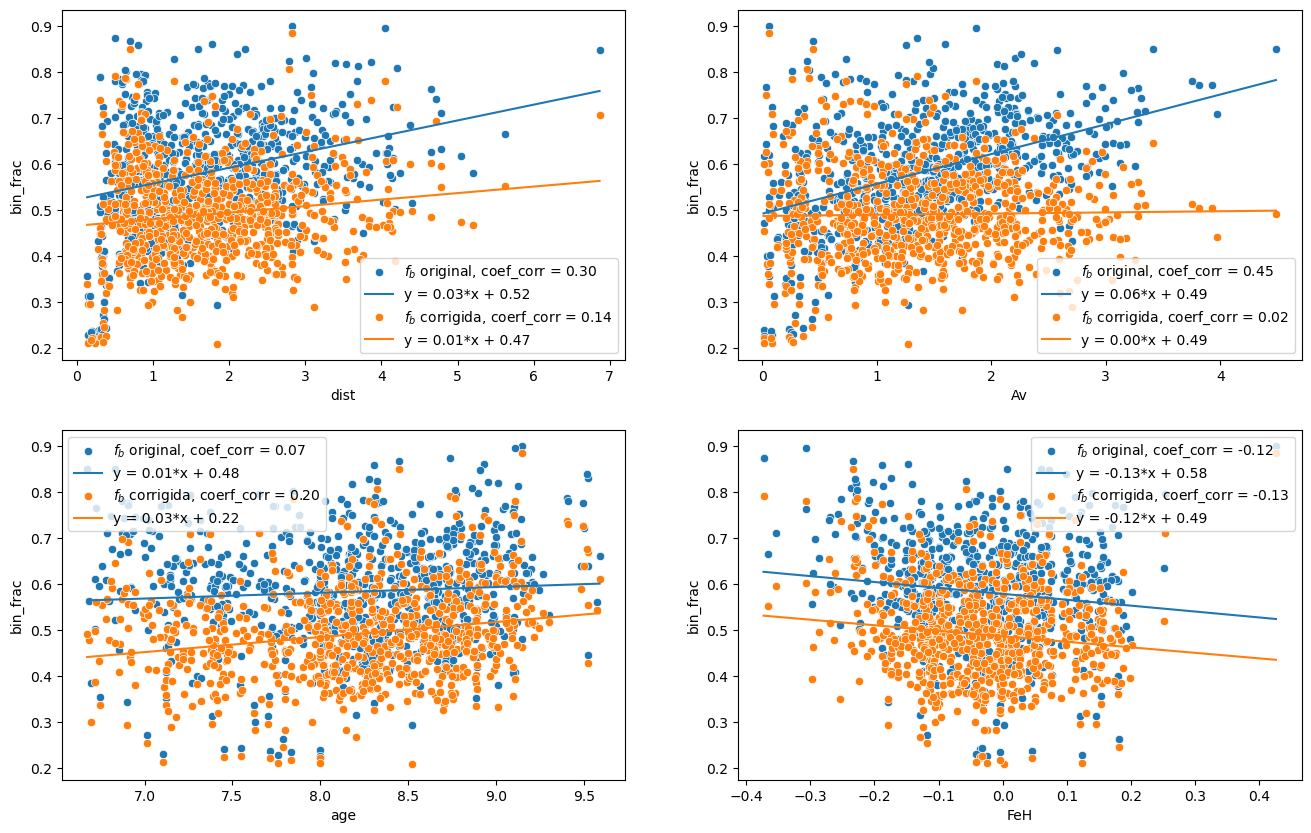

In [3]:
mean_bf_bench = benchmark_subsample['bin_frac'].mean()

bin_range = 0.5
Av = 0
while Av <= df['Av'].max():
    mask = (df['Av']>= Av) & (df['Av']< Av+bin_range)
    aux = df[mask]
    if len(aux) > 0:
        mean_bf_aux = aux['bin_frac'].mean()
        shift = mean_bf_aux - mean_bf_bench
        df.loc[mask, 'bin_frac_corr1'] = aux['bin_frac'] - shift

    Av += bin_range


fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    coef_corr = pearsonr(df[x],df['bin_frac'])
    sns.scatterplot(data=df, x =x, y=y, ax=axs[i,j],label=fr'$f_b$ original, coef_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df[y])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    
    coef_corr = pearsonr(df[x],df['bin_frac_corr1'])
    sns.scatterplot(x = df[x], y= df['bin_frac_corr1'], ax=axs[i,j],label=f'$f_b$ corrigida, coerf_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac_corr1'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    

                
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1

In [4]:
print(f'Média da amostra benchmark = {mean_bf_bench:.2f}')
print(f'Média dos valores corrigidos = {df['bin_frac_corr1'].mean():.2f}')

Média da amostra benchmark = 0.49
Média dos valores corrigidos = 0.49


## Usando média móvel

$MM_i = \frac{1}{w}\sum_{_{k=i-w/2}}^{i+w/2} f_{b_k}$

w é o tamanho da janela

A correção na fração de binárias foi calculada como:

$f_{b_{corrigido}} = f_b - (MM - \mathrm{media \ f_b \ bench})$


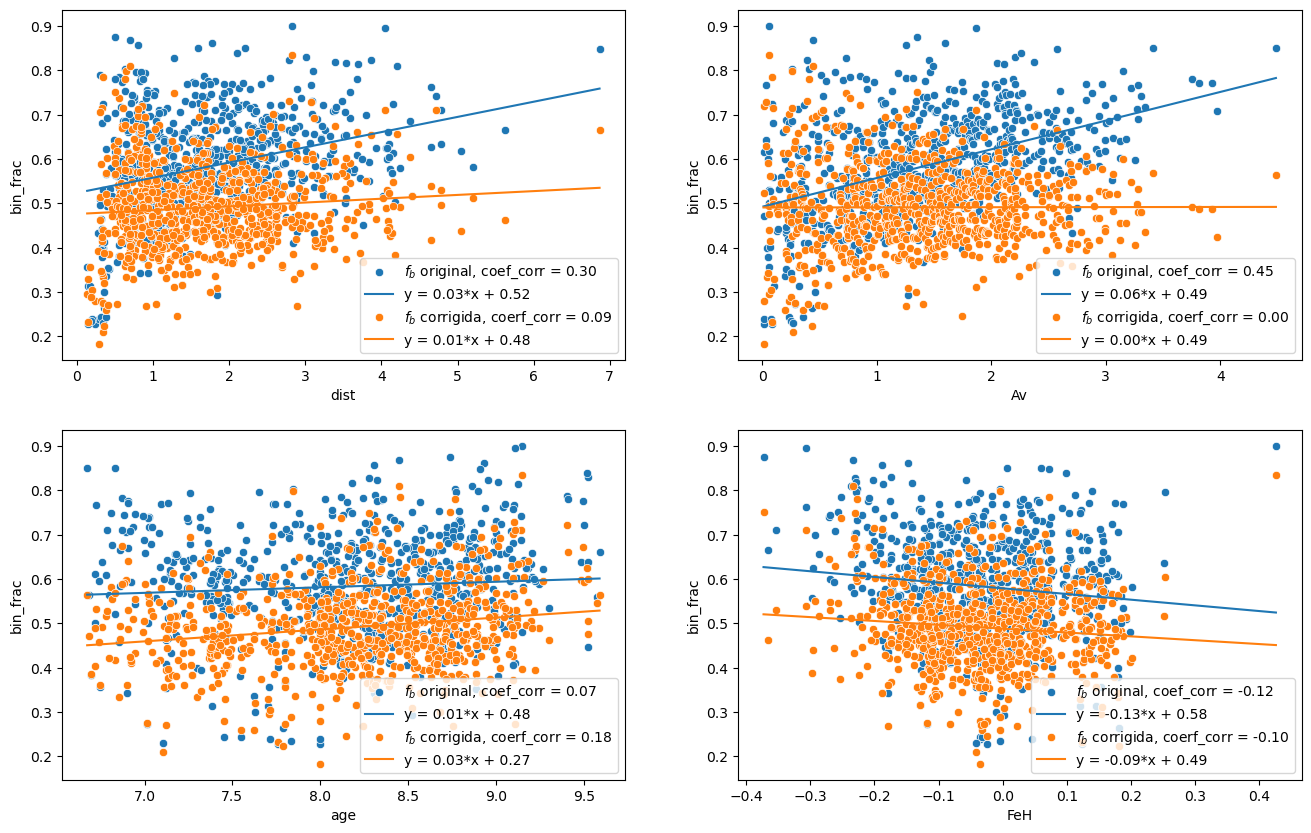

In [5]:
df = df.sort_values('Av').copy()

window = 5 
mm = df['bin_frac'].rolling(window=window, center=True, min_periods=1).mean()

df['bin_frac_corr2'] = df['bin_frac'] - (mm - mean_bf_bench)


mean_bf_bench = benchmark_subsample['bin_frac'].mean()

bin_range = 0.5
Av = 0
while Av <= df['Av'].max():
    mask = (df['Av']>= Av) & (df['Av']< Av+bin_range)
    aux = df[mask]
    if len(aux) > 0:
        mean_bf_aux = aux['bin_frac'].mean()
        shift = mean_bf_aux - mean_bf_bench
        df.loc[mask, 'bin_frac_corr1'] = aux['bin_frac'] - shift

    Av += bin_range


fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    coef_corr = pearsonr(df[x],df['bin_frac'])
    sns.scatterplot(data=df, x =x, y=y, ax=axs[i,j],label=fr'$f_b$ original, coef_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df[y])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    
    coef_corr = pearsonr(df[x],df['bin_frac_corr2'])
    sns.scatterplot(x = df[x], y= df['bin_frac_corr2'], ax=axs[i,j],label=f'$f_b$ corrigida, coerf_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac_corr2'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    

                
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1

In [6]:
print(f'Média da amostra benchmark = {mean_bf_bench:.2f}')
print(f'Média dos valores corrigidos = {df['bin_frac_corr2'].mean():.2f}')

Média da amostra benchmark = 0.49
Média dos valores corrigidos = 0.49


### Comparação das correções

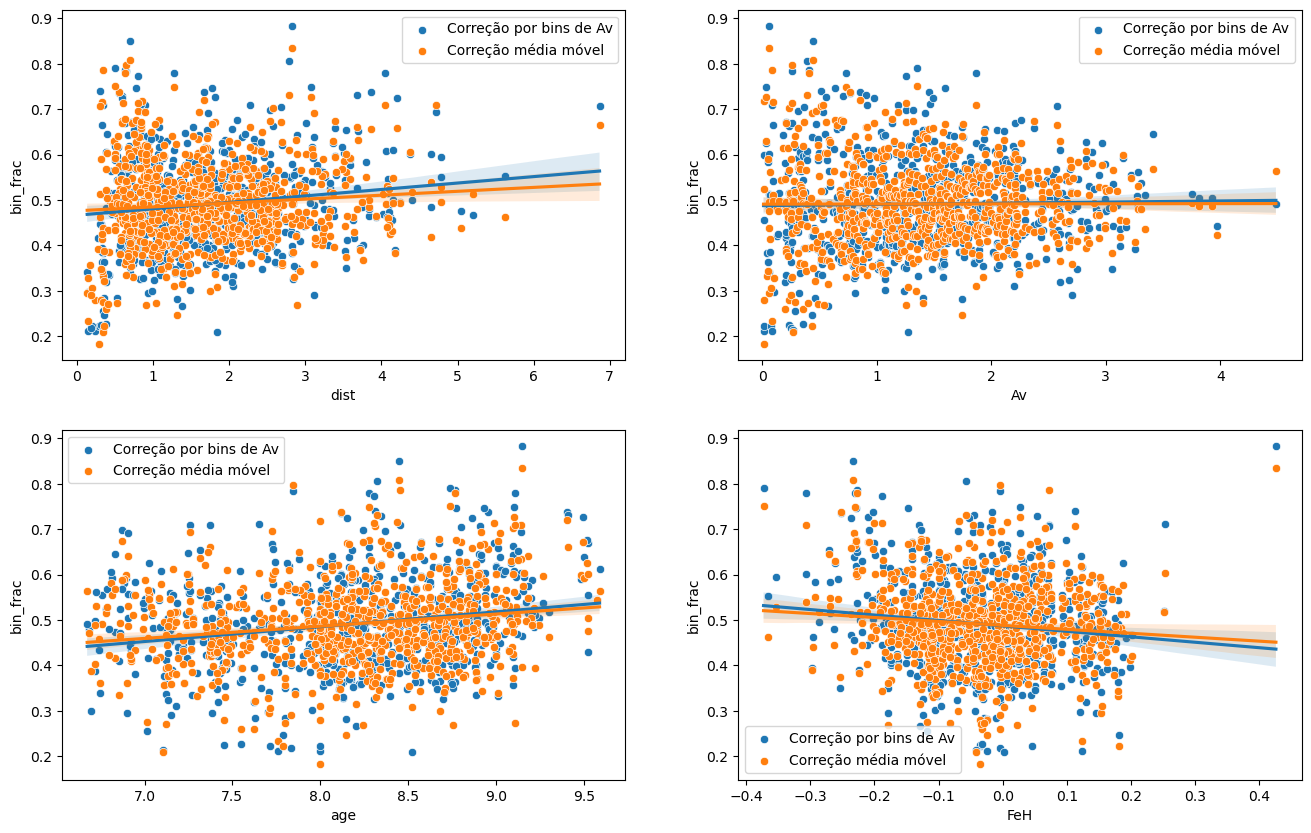

In [7]:
fig, axs = plt.subplots(2,2, figsize=(16,10))

xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    sns.scatterplot(data=df, x =x, y=df['bin_frac_corr1'], ax=axs[i,j],label=r'Correção por bins de Av')
    sns.regplot(data=df, x = x, y = df['bin_frac_corr1'], ax = axs[i,j], scatter=False,)
    
    sns.scatterplot(x = df[x], y= df['bin_frac_corr2'], ax=axs[i,j],label=r'Correção média móvel')
    sns.regplot(x = df[x], y = df['bin_frac_corr2'], ax = axs[i,j], scatter=False,)
    
    axs[i,j].set_ylabel('bin_frac')
    j = j+1
    if j>1:
        j=0
        i = i+1

# Correção por similaridade

Estimar a correção baseado na similaridade dos aglomerados e a partir do valor corrigido de $f_b$ refazer todas as análises aplicando bootstrap para estimar as incertezas

In [147]:
def find_k_nearest_cluster(df, idx, k=5, av_lim=.5, dist_lim=1.5):
    """
    Função que encontra os k aglomerados mais próximos em idade, metalicidade, massa total e quantidade de membros, dentro de uma subamostra de
    aglomerados com distâncias e avermelhamentos baixos.
    
    A função recebe os seguintes parâmetros:
    df -> dataframe com as propriedades de todos os aglomerados
    idx -> indice do aglomerado que queremos encontrar seus semelhantes
    k -> número dos aglomerados mais próximos que a função vai retornar
    av_lim -> avermelhamento máximo considerado para a subamostra de referencia
    dist_lim -> distância máxima considerada para a subamostra de referência

    E retorna os indices e as distâncias dos k-aglomerados mais próximos
    """
    
    params = ['age', 'FeH', 'mass_total', 'n_members']
    mask_ref = (df.Av < av_lim) & (df.dist < dist_lim) & (df.index != idx)
    ref_sample = df[mask_ref]   
    dists = []

    for cluster in ref_sample.index:
        d = distance.euclidean(ref_sample.loc[cluster, params],
                               df.loc[idx, params])
        dists.append((d, cluster))

    dists.sort(key=lambda x: x[0])
    return dists[:k] 

def corr_fb(df, idx, q=0, k=5, av_lim=.5, dist_lim=1.5,):
    """
    Retorna o valor corrigido de fb. O valor de fb corrigido considera a média ponderada dos k aglomerados mais próximos dentro da subamostra 
    de referência. Os pesos são inversamente proporcionais as distâncias (no espaço dos parâmetros) entre o aglomerado analisado e seus k-aglomerados
    semelhantes, dando maior peso aos que possuem uma distância menor.
    """
    nearest = find_k_nearest_cluster(df, idx, k, av_lim, dist_lim,) #Encontra os k semelhantes 

    #O parâmetro q define se a correção vai ser feita na coluna bin_frac, que considera a fração de binárias total do aglomerado ou em uma coluna com
    #bin_frac_q, que considera apenas binárias com razões de massa >= q
    if q==0:
        col = 'bin_frac'
    else:
        col = 'bin_frac_'+ str(q)
    fb_k = df.loc[idx, col]

    dists = np.array([d for d, _ in nearest])
    pesos = 1/dists
    pesos = pesos/pesos.max() #normaliza os pesos
    fb_ref = np.array([df.loc[c, col] for _, c in nearest]) #obtem os valores de fb dos k-aglomerados semelhantes
    return (fb_ref*pesos).sum()/pesos.sum()
    
for cluster in df.index:
    df.loc[cluster, 'bin_frac_ref'] = corr_fb(df, cluster,)
    df.loc[cluster, 'bin_frac_ref_0.5'] = corr_fb(df, cluster,q=0.5)

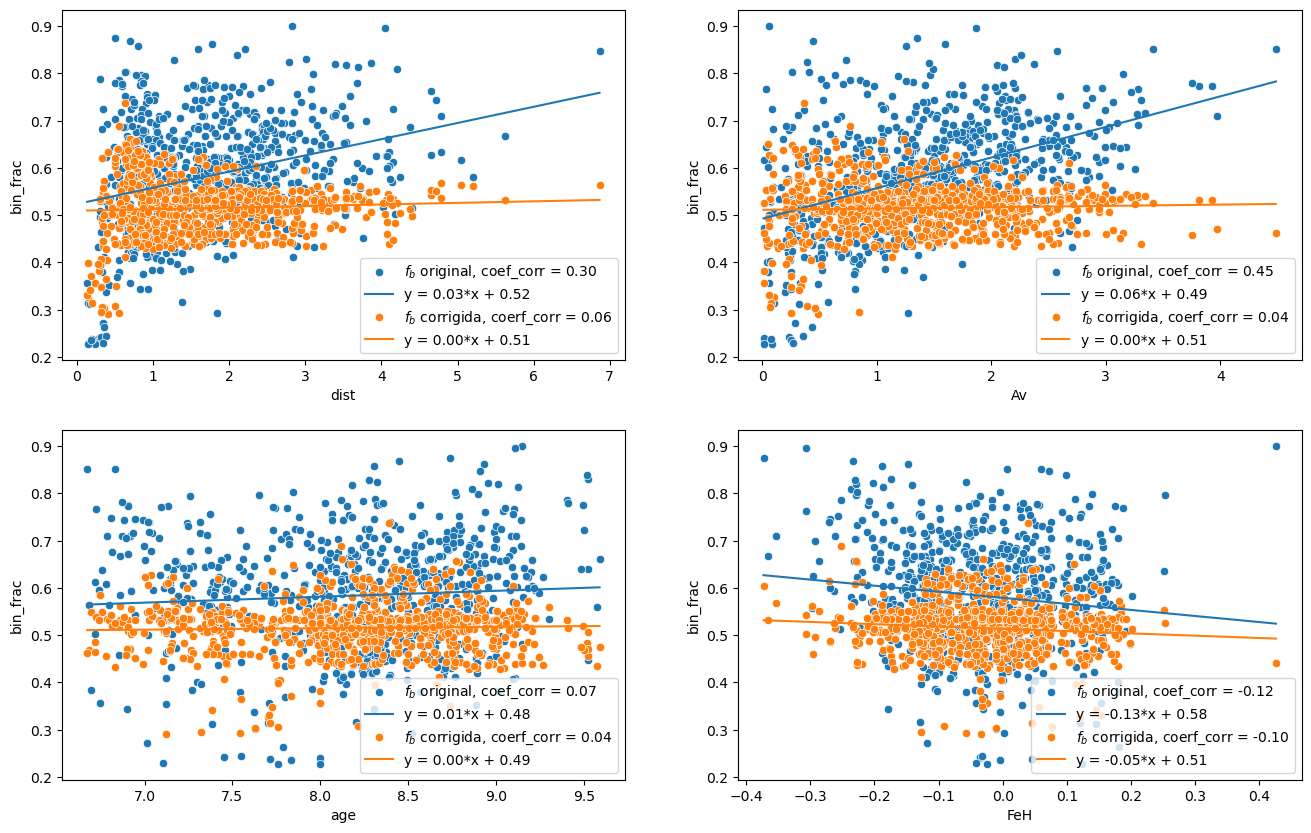

In [5]:
fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    coef_corr = pearsonr(df[x],df['bin_frac'])
    sns.scatterplot(data=df, x =x, y=y, ax=axs[i,j],label=fr'$f_b$ original, coef_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df[y])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    
    coef_corr = pearsonr(df[x],df['bin_frac_corr3'])
    sns.scatterplot(x = df[x], y= df['bin_frac_corr3'], ax=axs[i,j],label=f'$f_b$ corrigida, coerf_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac_corr3'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    

                
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1

Com os valores da fb corrigidos, a ideia vai ser fazer um bootstrap para "remover" aleatóriamente N binárias dos aglomerados. De modo que, para cada aglomerado, após a "remoção" dessas binárias sua fb seja igual a fb corrigida.
O número N de binárias que será 'removida' aleatoriamente de cada aglomerado será:

\begin{equation}
N = (fb - fb_{corr})*n_{membros}
\end{equation}

Ex: 100 estrelas, fb=0.9 e fb_corr = 0.5

Nesse caso N=40, indicando que 40 estrelas originalmente determinadas como binarias terão que ser aleatóriamente definidas como singulares.

# Problema quando fb_corr > fb, pois teria que adicionar binárias e isso teria implicações na estimativa da massa da companheira

Nesses casos em que fb_corr> fb, nenhuma alteração foi feita nos dados originais

213 aglomerados apresentaram esse comportamento

Aglomerados com fb_corr>fb: 213

           Av    dist  bin_frac  bin_frac_corr3
count  213.00  213.00    213.00          213.00
mean     0.92    1.34      0.46            0.53
std      0.58    0.83      0.08            0.06
min      0.01    0.15      0.23            0.30
25%      0.46    0.69      0.43            0.50
50%      0.86    1.11      0.47            0.53
75%      1.28    1.80      0.51            0.56
max      2.70    4.02      0.63            0.74




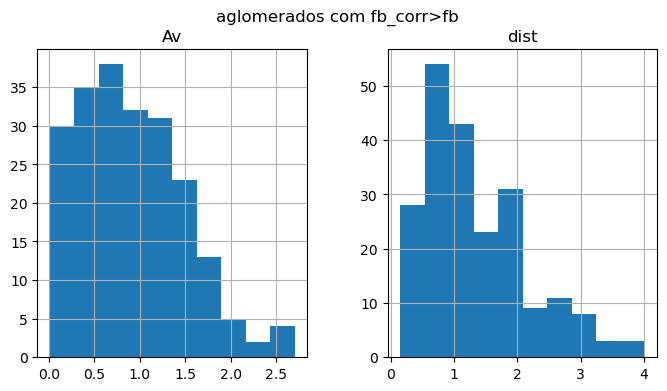

In [33]:
print(f'Aglomerados com fb_corr>fb: {len(df[(df['bin_frac']-df['bin_frac_corr3'])<=0])}\n')
print(df[(df['bin_frac']-df['bin_frac_corr3'])<=0][['Av', 'dist','bin_frac', 'bin_frac_corr3']].describe().round(2))
print('\n')
df[(df['bin_frac']-df['bin_frac_corr3'])<=0][['Av', 'dist']].hist(figsize=(8,4))
plt.suptitle('aglomerados com fb_corr>fb')
plt.show()

In [224]:
def calcula_sigma_sys(data, N, n_bootstrap=1000, random_state=None):
    
    rng = np.random.default_rng(random_state)

    clusters = data["Cluster"].unique()
    sigma_sys = []
    for j, cluster in enumerate(clusters):
        df_cluster = data[data["Cluster"] == cluster].copy()
        idx_bin = df_cluster[df_cluster["flag_binary"] == 1].index 
        idx_single = df_cluster[df_cluster["flag_binary"] == 0].index
        bootstrap_fb = []
        for _ in range(n_bootstrap):
            aux = df_cluster.copy(deep=True)          

            if N[j] > 0:
                N_boots = rng.integers(0, N[j])
                if N_boots>len(idx_bin):
                    N_boots=len(idx_bin)
                idx = rng.choice(idx_bin, size=np.abs(N_boots), replace=False)
                aux.loc[idx, "flag_binary"] = 0
            else:
                N_boots = rng.integers(N[j], 0)
                if np.abs(N_boots)>len(idx_single):
                    N_boots=len(idx_single)
                idx = rng.choice(idx_single, size= np.abs(N_boots), replace=False)
                aux.loc[idx, "flag_binary"] = 1

            fb = aux["flag_binary"].sum() / len(aux)
            bootstrap_fb.append(fb)

        sigma_sys.append(np.std(bootstrap_fb))

    return np.array(sigma_sys)

def calcula_sigma_bin(df, q):
    sigma_bin = []
    if q==0:
        for cluster in df.index:
            fb = df.loc[cluster]['bin_frac']
            n_memb = df.loc[cluster]['n_members']
            sigma_bin.append(np.sqrt(fb*(1-fb)/n_memb))
    else:
        for cluster in df.index:
            fb = df.loc[cluster]['bin_frac_'+str(q)]
            n_memb = df.loc[cluster]['n_members_'+str(q)]
            sigma_bin.append(np.sqrt(fb*(1-fb)/n_memb))        
    return np.array(sigma_bin)
        
def calcula_N(df, q=0):
    if q == 0:
        N = (df['bin_frac']-df['bin_frac_ref'])*df['n_members']
    else:
        N = (df['bin_frac_'+str(q)]-df['bin_frac_ref_'+str(q)])*df['n_members_'+str(q)]
        
    N = np.where((N>=0)&(N<=1),1,N)
    N = np.where((N<=0)&(N>=-1),-1,N)
    return np.array(N)
    
def calcula_err_fb(df, data, q, n_bootstrap=1000, random_state=1):
    
    N = calcula_N(df, q)    
    data['flag_binary'] = np.where(data["q"] > q, 1, 0) 
    
    sigma_sys = calcula_sigma_sys(data, N, n_bootstrap, random_state)
    sigma_bin = calcula_sigma_bin(df, q)
    sigma_fb = np.sqrt(sigma_bin**2 + sigma_sys**2)
    
    return sigma_fb




df['e_bin_frac'] = calcula_err_fb(df, data, q=0, n_bootstrap=1000, random_state=1)
df['e_bin_frac_0.5'] = calcula_err_fb(df, data, q=0.5, n_bootstrap=1000, random_state=1)
df.to_csv(r'Dados\results.csv', index=True)

In [225]:
df.sort_values(by='e_bin_frac')[['dist','Av','age','FeH','bin_frac','e_bin_frac', 'bin_frac_ref']]

,dist,Av,age,FeH,bin_frac,e_bin_frac,bin_frac_ref
Cluster,,,,,,,
NGC_6134,1.078,1.300,9.096,0.025,0.503751,0.013359,0.505642
NGC_1912,1.069,0.998,8.505,-0.022,0.444580,0.014694,0.437431
NGC_2539,1.239,0.135,8.890,-0.005,0.441219,0.016201,0.431649
NGC_2287,0.714,0.225,8.296,-0.078,0.420499,0.016795,0.439094
NGC_2548,0.747,0.127,8.714,-0.002,0.437288,0.017141,0.443067
...,...,...,...,...,...,...,...
Berkeley_8,3.013,2.209,9.527,-0.175,0.831382,0.197682,0.455686
IC_4665,0.310,0.510,8.309,0.112,0.788845,0.204976,0.394115
Bica_2,1.588,4.486,6.673,0.059,0.851163,0.209643,0.463334


In [226]:
df.sort_values(by='e_bin_frac_0.5')[['dist','Av','age','FeH','bin_frac_0.5','e_bin_frac_0.5', 'bin_frac_ref_0.5']]

,dist,Av,age,FeH,bin_frac_0.5,e_bin_frac_0.5,bin_frac_ref_0.5
Cluster,,,,,,,
NGC_6134,1.078,1.300,9.096,0.025,0.332262,0.013584,0.325406
NGC_2360,1.036,0.396,9.106,-0.083,0.263736,0.014239,0.252849
NGC_1912,1.069,0.998,8.505,-0.022,0.278928,0.014316,0.268555
NGC_2287,0.714,0.225,8.296,-0.078,0.243101,0.014693,0.256424
NGC_2539,1.239,0.135,8.890,-0.005,0.246734,0.015007,0.255551
...,...,...,...,...,...,...,...
Haffner_16,2.786,0.388,8.324,-0.058,0.672727,0.193555,0.276087
UPK_40,0.636,1.132,8.678,-0.128,0.658824,0.194411,0.253262
UPK_54,0.798,1.252,8.305,-0.188,0.731343,0.194651,0.346582


In [50]:
def bootstrap(df, N, n_bootstrap=1000, random_state=None):
    inicio = time.perf_counter()
    rng = np.random.default_rng(random_state) #define o geraador de números aleatórios
    clusters = df['Cluster'].unique()
    list_idx_bin = []
    list_df_clusters =[]
    for cluster in clusters:
        #seleciona, para cada aglomerado, os indices que contenham apenas estrelas originalmente determinadas como binárias
        list_idx_bin.append(df[(df['flag_binary'] == 1) & (df['Cluster']==cluster)].index)
        list_df_clusters.append(df[df['Cluster']==cluster].copy(deep=True))
    resultados = []
    
    for i in range(n_bootstrap):
        clusters_bootstrap = []
        for j in range(0,len(clusters)):
            aux = list_df_clusters[j].copy(deep=True)
            if N[j] == 0:
                clusters_bootstrap.append(aux)
            else:    
                idx_sorteados = rng.choice(list_idx_bin[j], size=int(N[j]), replace=False)
                aux.loc[idx_sorteados, 'flag_binary'] = 0
                clusters_bootstrap.append(aux['flag_binary'])
        
        resultados.append(pd.concat(clusters_bootstrap, ignore_index=False))
        print(f'Concluído: {i+1}/{n_bootstrap}')  
    fim = time.perf_counter()    
    tempo_decorrido = fim - inicio
    print(f"Tempo de execução: {tempo_decorrido:.6f} segundos")    
    return resultados


    

In [ ]:
data['flag_binary'] = np.where(data["q"] > 0, 1, 0) # define 1 se binária, 0 se singular

# calcula o numero de flags de binárias que será alterado para cada aglomerado
N = (df['bin_frac']-df['bin_frac_corr3'])*df['n_members']
N = np.where(N<=0,0,N) #Casos que fb_corr> fb define N=0

resultados_bootstrap = bootstrap(data, N, n_bootstrap=1000, random_state=1)

Concluído: 1/1000
Concluído: 2/1000
Concluído: 3/1000
Concluído: 4/1000
Concluído: 5/1000
Concluído: 6/1000
Concluído: 7/1000
Concluído: 8/1000
Concluído: 9/1000
Concluído: 10/1000
Concluído: 11/1000
Concluído: 12/1000
Concluído: 13/1000
Concluído: 14/1000
Concluído: 15/1000
Concluído: 16/1000
Concluído: 17/1000
Concluído: 18/1000
Concluído: 19/1000
Concluído: 20/1000
Concluído: 21/1000
Concluído: 22/1000
Concluído: 23/1000
Concluído: 24/1000
Concluído: 25/1000
Concluído: 26/1000
Concluído: 27/1000
Concluído: 28/1000
Concluído: 29/1000
Concluído: 30/1000
Concluído: 31/1000
Concluído: 32/1000
Concluído: 33/1000
Concluído: 34/1000
Concluído: 35/1000
Concluído: 36/1000
Concluído: 37/1000
Concluído: 38/1000
Concluído: 39/1000
Concluído: 40/1000
Concluído: 41/1000
Concluído: 42/1000
Concluído: 43/1000
Concluído: 44/1000
Concluído: 45/1000
Concluído: 46/1000
Concluído: 47/1000
Concluído: 48/1000
Concluído: 49/1000
Concluído: 50/1000
Concluído: 51/1000
Concluído: 52/1000
Concluído: 53/1000
Co

In [ ]:
list_resultados = []
for i in range(0, len(resultados_bootstrap)):
    resultados_bootstrap[i]['q'] = resultados_bootstrap[i]['q']*resultados_bootstrap[i]['flag_binary']
    
    min_mass, max_mass, mass, er_mass, P_prim, P_sec, P_BS, n_stars, qs = calcula_probabilidades(resultados_bootstrap[i], 'media')
    
    list_resultados.append(pd.DataFrame({'min_mass': min_mass, 'max_mass': max_mass, 'mean_mass': mass, 'e_mean_mass': er_mass, 'P_prim': P_prim,
                                'P_comp': P_sec, 'P_BS': P_BS, 'n_stars': n_stars, 'q_prim': qs[0], 'q_comp': qs[1], 'q_BS': qs[2]
                                        })
                          )        
    #print(f'concluído: {i+1}/{len(resultados_bootstrap)}')

In [ ]:
x = list_resultados[0]['mean_mass'].values

Y = np.vstack([
    df['P_prim'].values
    for df in list_resultados
])

p5 = np.nanpercentile(Y, 5, axis=0)
p50 = np.nanpercentile(Y, 50, axis=0)
p95 = np.nanpercentile(Y, 95, axis=0)


plt.figure(figsize=(7,5))

plt.fill_between(
    x,
    p5,
    p95,
    alpha=0.3,
)

plt.plot(x, p50, lw=2, label='Mediana')

plt.xlabel('mean_mass')
plt.ylabel('P_prim')
plt.legend()
plt.tight_layout()
plt.xscale('log')
plt.show()






In [16]:
data

,pmRApmDEcor,PlxpmRAcor,PlxpmDEcor,RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Plx,e_Plx,pmRA,...,e_mass_system,r,r/rh,e_r,e_r/rh,t_seg,tau,dinamical_state,Cluster,flag_binary
0,0.3947,0.2452,0.3009,51.878597,0.0382,34.373353,0.0302,1.5327,0.0431,-1.743,...,0.000627,6.927651,1.499220,4.820209,0.297981,8.894829,3.075582,Moderately relaxed,ASCC_10,0
1,0.0225,0.1502,0.2691,51.655044,0.0646,34.830793,0.0464,1.5148,0.0751,-1.671,...,0.012334,2.937150,0.635632,4.939914,0.126336,10.409995,3.075582,Moderately relaxed,ASCC_10,0
2,0.1962,0.0973,0.1962,51.562305,0.0183,35.038219,0.0152,1.6062,0.0227,-1.759,...,0.249046,3.214852,0.695730,4.802486,0.138281,2.966531,3.075582,Moderately relaxed,ASCC_10,0
3,-0.2873,-0.0543,0.3951,51.669998,0.1343,34.751452,0.1017,1.5993,0.1523,-1.613,...,0.033510,3.463661,0.749575,4.689042,0.148983,7.266997,3.075582,Moderately relaxed,ASCC_10,1
4,0.3337,0.2404,0.2745,52.247907,0.0164,35.100717,0.0130,1.5441,0.0195,-1.705,...,0.302783,3.352865,0.725597,4.859636,0.144218,4.521865,3.075582,Moderately relaxed,ASCC_10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152517,-0.0501,0.1582,0.0278,106.005495,0.0761,-11.604856,0.0820,0.9346,0.0905,-4.379,...,0.004198,2.514689,1.017729,1.770326,0.087713,10.482411,0.181549,Not very relaxed,vdBergh_92,0
152518,-0.1744,-0.0782,0.0656,106.083301,0.0667,-11.372899,0.0733,0.9971,0.0824,-4.507,...,0.092548,2.184711,0.884182,1.728145,0.076203,10.607156,0.181549,Not very relaxed,vdBergh_92,0
152519,-0.2079,0.1070,0.2052,106.166213,0.2012,-11.472170,0.2035,0.8268,0.2374,-4.409,...,0.072986,1.820391,0.736737,1.762198,0.063496,17.735239,0.181549,Not very relaxed,vdBergh_92,0
152520,-0.1727,0.2140,0.0657,106.163751,0.0935,-11.482433,0.0983,0.9023,0.1171,-4.268,...,0.036569,1.753969,0.709855,1.662880,0.061179,11.846586,0.181549,Not very relaxed,vdBergh_92,0


In [9]:
df[['bin_frac','e_bin_frac']].sort_values(by='e_bin_frac').round(2)

,bin_frac,e_bin_frac
Cluster,,
NGC_2539,0.44,0.03
NGC_2287,0.42,0.03
IC_2488,0.47,0.04
NGC_2360,0.41,0.04
COIN-Gaia_18,0.47,0.05
...,...,...
Berkeley_8,0.83,0.39
Bica_2,0.85,0.39
UBC_433,0.90,0.40


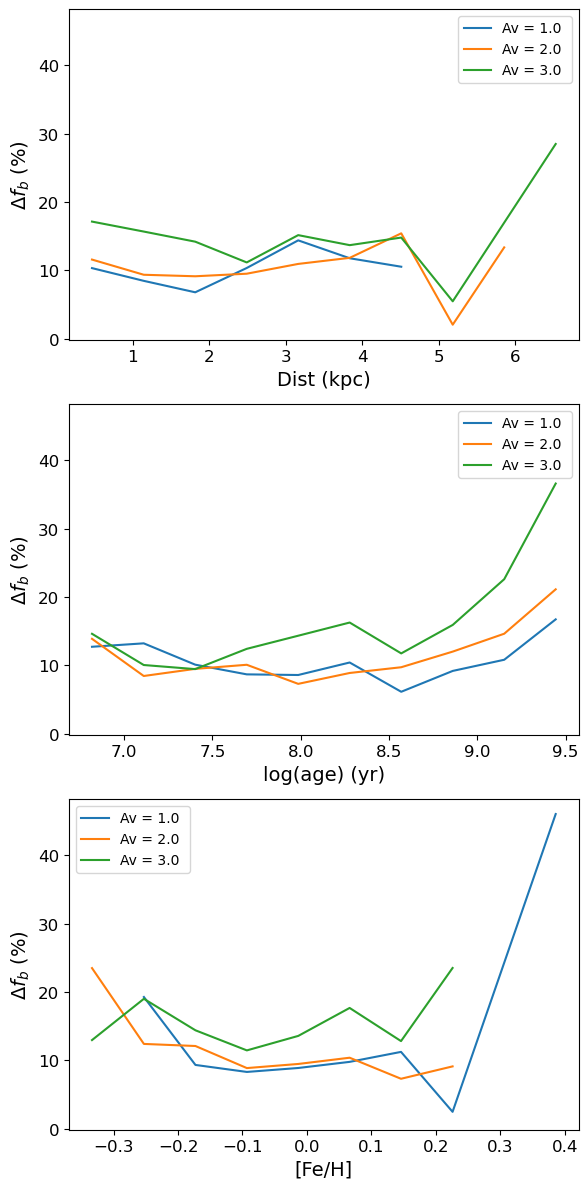

In [31]:
fig, axs = plt.subplots(3,1, figsize = (6,12), sharey=True)


# Agrupamento por faixas de extinção Av
aux['Av_group'] = pd.cut(aux['Av'], bins=[0, 1.0, 2.0, 3.0], labels=['Av = 1.0 ', 'Av = 2.0', 'Av = 3.0',])

# Divide a variável 'dist' (distância) em 10 faixas
aux['dist_bin'] = pd.cut(aux['dist'], bins=10)
aux['dist_center'] = aux['dist_bin'].apply(lambda x: x.mid)

# Agrupa por faixa de dist e grupo de Av, calcula média de e_bin_frac
grouped = aux.groupby(['Av_group', 'dist_center'])['e_bin_frac'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='dist_center', y=grouped['mean']*100, hue='Av_group', ax= axs[0])
axs[0].set_xlabel(r'Dist (kpc)', fontdict=font)



aux['age_bin'] = pd.cut(aux['age'], bins=10)
aux['age_center'] = aux['age_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'age_center'])['e_bin_frac'].agg(['mean',]).reset_index()
grouped['mean'] = grouped['mean']*100


sns.lineplot(data=grouped, x='age_center', y=grouped['mean'], hue='Av_group', ax= axs[1])
axs[1].set_xlabel(r'log(age) (yr)', fontdict=font)

aux['FeH_bin'] = pd.cut(aux['FeH'], bins=10)
aux['FeH_center'] = aux['FeH_bin'].apply(lambda x: x.mid)


grouped = aux.groupby(['Av_group', 'FeH_center'])['e_bin_frac'].agg(['mean',]).reset_index()

sns.lineplot(data=grouped, x='FeH_center', y=grouped['mean']*100, hue='Av_group', ax= axs[2])
axs[2].set_xlabel(r'[Fe/H]', fontdict=font)

axs[0].set_ylabel(r'$\Delta{f_b}$ (%)', fontdict= font)
axs[1].set_ylabel(r'$\Delta{f_b}$ (%)', fontdict= font)
axs[2].set_ylabel(r'$\Delta{f_b}$ (%)', fontdict= font)

for ax in axs:
    ax.tick_params(labelsize=labelsize)
    ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('Figures/err_fb.png',bbox_inches='tight', dpi=300)
plt.show()


In [28]:
aux['e_bin_frac']=np.abs(aux['bin_frac']-aux['bin_frac_corr3'])

In [29]:
aux['e_bin_frac'].describe()

count    771.000000
mean       0.107986
std        0.082443
min        0.000031
25%        0.041307
50%        0.092947
75%        0.155138
max        0.460230
Name: e_bin_frac, dtype: float64